#### Binary classification  (BENIGN vs ATTACK)

In [ ]:
import pandas as pd
import numpy as np
import joblib, os, time, warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split

In [7]:
df = pd.read_csv("../dataset/binary_modal_dataset.csv")

print("Train Shape:", df.shape)

Train Shape: (140000, 67)


In [8]:
X = df.drop('Label', axis=1)
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  
)
X_train.shape, X_test.shape

((112000, 66), (28000, 66))

In [11]:
gbm_bin = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    max_features='sqrt',
    min_samples_leaf=20,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=3
)

print("Intialize the GBM")

Intialize the GBM


In [12]:
bin_names = ['BENIGN', 'ATTACK']
sw_bin = compute_sample_weight('balanced', y_train)


In [13]:
print('Training GBM (binary) ...')
t0 = time.time()
gbm_bin.fit(X_train, y_train, sample_weight=sw_bin)

Training GBM (binary) ...
      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.2912           0.0951           25.39s
         2           1.2073           0.0840           23.81s
         3           1.1289           0.0786           25.83s
         4           1.0577           0.0712           28.73s
         5           0.9933           0.0638           26.66s
         6           0.9318           0.0621           24.75s
         7           0.8758           0.0560           23.70s
         8           0.8252           0.0504           22.85s
         9           0.7784           0.0478           22.28s
        10           0.7330           0.0450           21.62s
        11           0.6908           0.0409           21.01s
        12           0.6525           0.0390           20.59s
        13           0.6153           0.0368           20.24s
        14           0.5828           0.0339           19.95s
        15           0.5503           0.030

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,150
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


#### Model Evaluation

In [14]:
y_pred = gbm_bin.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.99925


In [16]:
binary_label = joblib.load('../models/Binary_LabelEncoder.pkl')
class_names = list(binary_label.classes_)
print("\nClassification Report")
print(classification_report(y_test, y_pred, target_names=class_names))


Classification Report
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00      6000
      BENIGN       1.00      1.00      1.00     22000

    accuracy                           1.00     28000
   macro avg       1.00      1.00      1.00     28000
weighted avg       1.00      1.00      1.00     28000



In [22]:
import seaborn as sns

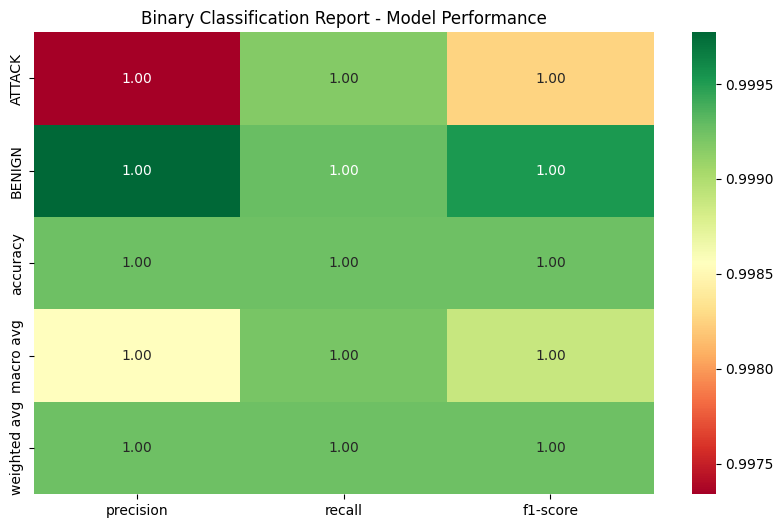

In [23]:
report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)

report_df = pd.DataFrame(report_dict).iloc[:-1, :].T

plt.figure(figsize=(10, 6))
sns.heatmap(report_df, annot=True, cmap='RdYlGn', fmt='.2f')

plt.title('Binary Classification Report - Model Performance')
plt.savefig('../results/binary_classification_report.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
print("\nConfusion Matrix")
confusion_matrix(y_test, y_pred)


Confusion Matrix


array([[ 5995,     5],
       [   16, 21984]])

In [19]:
fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['BENIGN', 'ATTACK'])
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title("Gradient Boost — Confusion Matrix (CIC-DDoS 2019)", fontsize=13)
plt.tight_layout()
cm_path = os.path.join('../results/binary_confusion_matrix5.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"\n  ✓ Confusion matrix saved → {cm_path}")


  ✓ Confusion matrix saved → ../results/binary_confusion_matrix5.png


In [ ]:
joblib.dump(gbm_bin, "../models/binary_gb_model.pkl")

['../models/binary_gb_model.pkl']